In [1]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.cluster import KMeans  
from sklearn.feature_selection import mutual_info_classif

from src.data_preprocessing import scale,encode
from src.data_feature_engineering import features


In [3]:
df=pd.read_csv("data/clean/Diabetes Classifier Clean.csv")
y=df['diagnosis']
X=df.drop(['diagnosis'],axis=1)

In [4]:
X=encode(X,'gender')
gender=X['gender']
X.drop(['gender'],axis=1)

,age,bmi,chol,tg,hdl,ldl,cr,bun
0,50,24,4.20,0.90,2.40,1.40,46.0,4.70
1,26,23,3.70,1.40,1.10,2.10,62.0,4.50
2,33,21,4.90,1.00,0.80,2.00,46.0,7.10
3,45,21,2.90,1.00,1.00,1.50,24.0,2.30
4,50,24,3.60,1.30,0.90,2.10,50.0,2.00
...,...,...,...,...,...,...,...,...
5127,54,23,5.00,1.50,1.24,2.98,77.0,3.50
5128,50,22,4.37,2.09,1.37,2.29,47.3,4.40
5129,67,24,3.89,1.38,1.14,2.17,70.6,4.73
5130,60,29,5.91,1.29,1.73,2.85,50.2,7.33


Cluster 1      0.231768
Age_x_BMI      0.226799
age            0.193691
BMI/HDL+LDL    0.167978
lipids         0.161825
HDL_x_LDL      0.152508
ldl            0.146197
hdl            0.144168
BMI/LDL        0.136277
Cluster 3      0.123270
Cluster 5      0.117414
bmi            0.114326
chol/ldl       0.114249
Cluster 4      0.113659
Cluster 0      0.112986
tg             0.085182
chol           0.056798
cr             0.049047
bun            0.047836
Cluster 2      0.030394
bun_x_cr       0.026694
gender         0.003201
dtype: float64


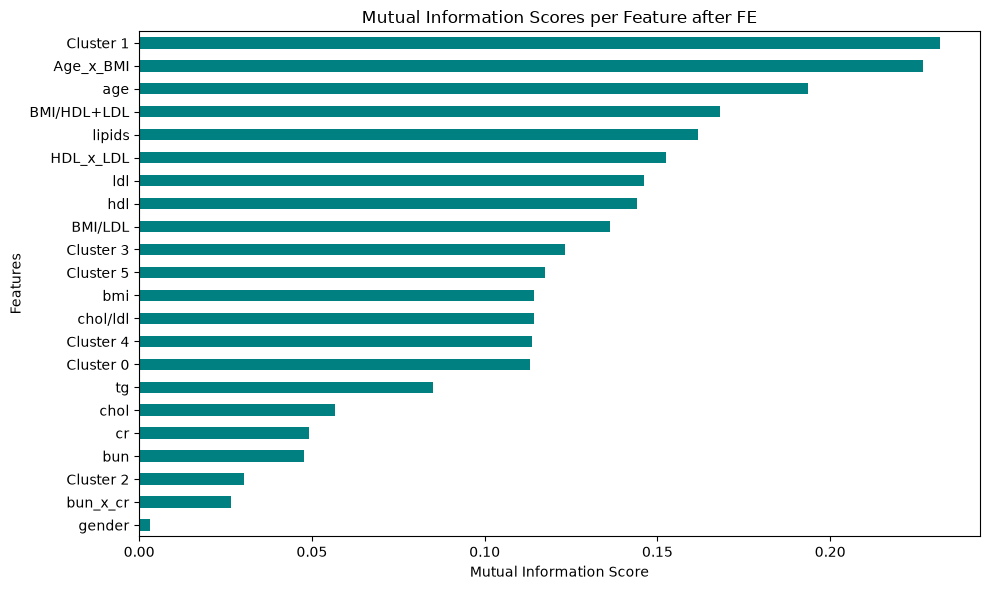

In [5]:

X=features(X,gender)

features= X.columns

mi_scores=mutual_info_classif(X,y,random_state=42,n_jobs=-1)

mi_scores_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)

print(mi_scores_series)     

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='teal')
plt.title('Mutual Information Scores per Feature after FE')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Top-down display
plt.tight_layout()
plt.show()

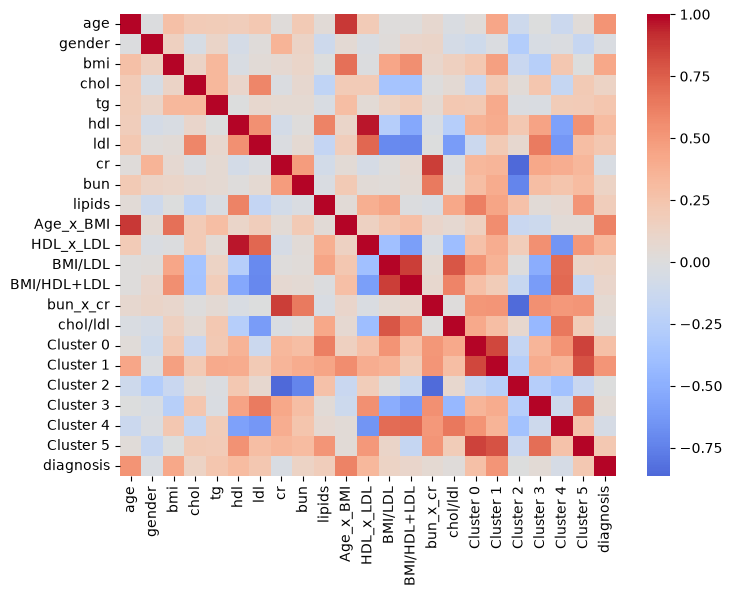

In [6]:


X_sub=pd.concat([X,df['diagnosis']],axis=1)
corr = X_sub.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=False,
            cmap="coolwarm",
            center=0)
plt.show()